# Phase 11b — DL Entity Embeddings vs. Hand-crafted Features (supplementary)

**คำถามธุรกิจ:** Phase 11 (feature ablation) พบว่าฟีเจอร์ปฏิทิน/lifecycle สำคัญที่สุด ส่วน price และ external enrichment เพิ่มความแม่นยำ ~0 คำถามต่อยอดคือ **deep learning entity embeddings** ของ `sku`/`channel`/`region` (แทน categorical เดิม) จะเจอ signal ที่ฟีเจอร์ hand-crafted พลาดไปหรือไม่

**วิธีทดสอบ:** เทรน entity embedding network เล็กๆ (PyTorch, 1 hidden layer) แยกใหม่ทุก fold บน **train_weeks ของ fold นั้นเท่านั้น** (ไม่แตะ val_weeks เพื่อป้องกัน leakage) ได้ embedding vector ของ `sku` (4 มิติ), `channel` (2 มิติ), `region` (2 มิติ) รวม 8 คอลัมน์ใหม่ แล้วเทียบ Global pooled LightGBM (โมเดลเดียวกับ Phase 7/11) บน `ALL_FEATURE_COLS` (baseline) กับ `ALL_FEATURE_COLS + dl_embedding_cols()` บน walk-forward CV fold ชุดเดียวกับทุก phase ก่อนหน้า

**หมายเหตุสำคัญ:** นี่คือการทดลองเสริม (supplementary, ตั้งชื่อตาม `02_promotions/08b_promotion_robustness.ipynb`) ไม่ใช่ phase ใหม่ในลำดับหลัก — ไม่แตะ `ALL_FEATURE_COLS`, `engineer.py`, `enrich.py`, หรือ notebook อื่นใดที่มีอยู่แล้ว โมดูล `src/features/dl_embeddings.py` เป็นไฟล์ใหม่ที่แยกต่างหาก ไม่ถูก import โดยโค้ด production ใดๆ

In [1]:
import sys
sys.path.insert(0, '../../src')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from splits.walk_forward import WalkForwardSplitter
from models.forecast import prepare_categoricals, fit_predict_lgb, ALL_FEATURE_COLS
from models.metrics import score_all
from features.dl_embeddings import fit_fold_embeddings, transform_with_fold_embeddings, dl_embedding_cols

pd.set_option('display.width', 160)

df = pd.read_csv('../../data/processed/weekly_features.csv', parse_dates=['week'])
dfc = prepare_categoricals(df)

splitter = WalkForwardSplitter(initial_train_end='2023-09-30', val_fold_weeks=8, final_test_weeks=10)
folds, final_test_weeks = splitter.get_folds(dfc)
print(f'{len(folds)} CV folds, final holdout = {len(final_test_weeks)} weeks (untouched until Phase 13)')

7 CV folds, final holdout = 10 weeks (untouched until Phase 13)


## 1. Per-fold WAPE: baseline vs. baseline + DL entity embeddings

`use_dl=True` เทรน embedding network ใหม่ทุก fold บน `train.` เท่านั้น (ดู `fit_fold_embeddings` — ไม่มีพารามิเตอร์ให้ `val` เข้าไปมีผลต่อการเทรนได้เลยแม้จะพยายาม) แล้ว merge embedding เข้ากับทั้ง train/val ด้วย `transform_with_fold_embeddings` (merge ตามค่า entity เท่านั้น ไม่ใช่ตามสัปดาห์หรือ target) ก่อนส่งต่อเข้า `fit_predict_lgb` ตัวเดิมที่ไม่ได้แก้ไขอะไรเลย

In [2]:
def cv_wape_per_fold(use_dl: bool):
    wapes = []
    for f in folds:
        train = dfc[dfc.week.isin(f.train_weeks)]
        val = dfc[dfc.week.isin(f.val_weeks)]
        if use_dl:
            embedding_tables = fit_fold_embeddings(train)
            train_ext = transform_with_fold_embeddings(train, embedding_tables)
            val_ext = transform_with_fold_embeddings(val, embedding_tables)
            pred = fit_predict_lgb(train_ext, val_ext, feature_cols=ALL_FEATURE_COLS + dl_embedding_cols())
            wapes.append(score_all(val_ext.target_next_week.values, pred)['WAPE'])
        else:
            pred = fit_predict_lgb(train, val, feature_cols=ALL_FEATURE_COLS)
            wapes.append(score_all(val.target_next_week.values, pred)['WAPE'])
    return wapes

baseline_wapes = cv_wape_per_fold(use_dl=False)
with_dl_wapes = cv_wape_per_fold(use_dl=True)

comparison = pd.DataFrame({
    'fold': np.arange(1, len(folds) + 1),
    'baseline_WAPE': baseline_wapes,
    'with_dl_embeddings_WAPE': with_dl_wapes,
})
comparison['diff'] = comparison['with_dl_embeddings_WAPE'] - comparison['baseline_WAPE']

summary = pd.DataFrame({
    'variant': ['ALL_FEATURE_COLS (baseline)', 'ALL_FEATURE_COLS + DL entity embeddings'],
    'mean_WAPE': [np.mean(baseline_wapes), np.mean(with_dl_wapes)],
    'std_WAPE': [np.std(baseline_wapes, ddof=1), np.std(with_dl_wapes, ddof=1)],
})

display(comparison.round(4))
display(summary.round(4))

,fold,baseline_WAPE,with_dl_embeddings_WAPE,diff
0,1,0.2324,0.2321,-0.0003
1,2,0.2317,0.2326,0.0009
2,3,0.2200,0.2190,-0.0010
3,4,0.2237,0.2236,-0.0001
4,5,0.2201,0.2201,0.0000
5,6,0.2166,0.2183,0.0017
6,7,0.2201,0.2204,0.0003


,variant,mean_WAPE,std_WAPE
0,ALL_FEATURE_COLS (baseline),0.2235,0.0062
1,ALL_FEATURE_COLS + DL entity embeddings,0.2237,0.0061


## 2. เปรียบเทียบ WAPE รายรอบเป็นกราฟ

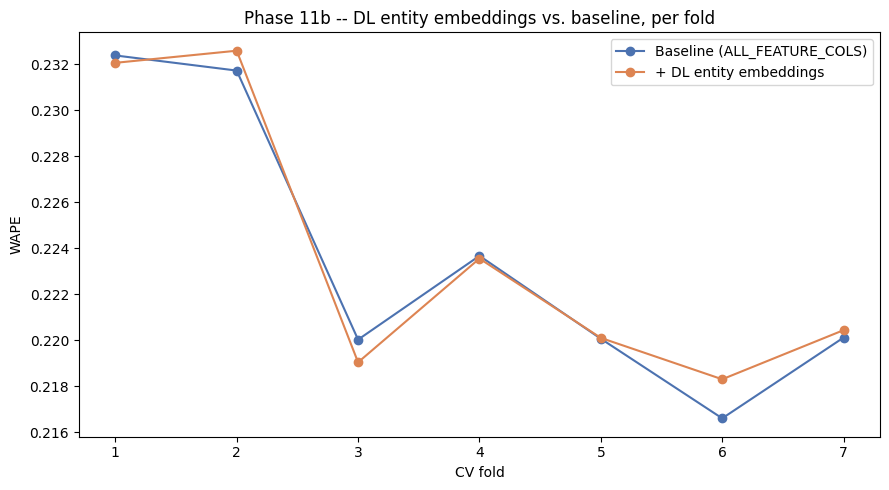

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
x = comparison['fold']
ax.plot(x, comparison['baseline_WAPE'], marker='o', label='Baseline (ALL_FEATURE_COLS)', color='#4C72B0')
ax.plot(x, comparison['with_dl_embeddings_WAPE'], marker='o', label='+ DL entity embeddings', color='#DD8452')
ax.set_xlabel('CV fold')
ax.set_ylabel('WAPE')
ax.set_title('Phase 11b -- DL entity embeddings vs. baseline, per fold')
ax.legend()
plt.tight_layout()
plt.savefig('../../reports/figures/phase11b_dl_feature_experiment.png', dpi=120)
plt.show()

## 3. Paired Significance Test

ต่างจาก Phase 11 ที่ทดสอบ 6 กลุ่มฟีเจอร์พร้อมกัน (ต้องใช้ Holm correction ควบคุม false-positive rate จากการทดสอบหลายคู่) ที่นี่มีการเปรียบเทียบ **แค่คู่เดียว** (baseline vs. with-DL-embeddings) — Holm-Bonferroni มีไว้ควบคุม family-wise error เมื่อทดสอบหลาย hypothesis พร้อมกัน เมื่อมี hypothesis เดียวจึงไม่มี multiplicity ให้ต้องปรับ raw p-value จาก paired t-test จึงเป็นค่าที่ใช้อ่านผลได้ตรงๆ

In [4]:
from scipy import stats

diff = comparison['with_dl_embeddings_WAPE'].to_numpy() - comparison['baseline_WAPE'].to_numpy()
t_stat, p_value = stats.ttest_rel(comparison['with_dl_embeddings_WAPE'], comparison['baseline_WAPE'])
n_folds = len(comparison)
se = diff.std(ddof=1) / np.sqrt(n_folds)
ci_low, ci_high = stats.t.interval(0.95, df=n_folds - 1, loc=diff.mean(), scale=se)

print(f'Mean WAPE diff (with_dl - baseline): {diff.mean():.4f} [95% CI {ci_low:.4f}, {ci_high:.4f}]')
print(f'Paired t-test (n={n_folds} folds): t={t_stat:.3f}, p={p_value:.3f}')
verdict = 'a significant difference WAS detected' if p_value < 0.05 else 'no significant difference was detected'
print(f'-- {verdict} at alpha=0.05 (single comparison, no multiplicity correction needed)')

Mean WAPE diff (with_dl - baseline): 0.0002 [95% CI -0.0006, 0.0010]
Paired t-test (n=7 folds): t=0.653, p=0.538
-- no significant difference was detected at alpha=0.05 (single comparison, no multiplicity correction needed)


## 4. การตีความผล

**ผลลัพธ์:** DL entity embeddings **ไม่ได้เพิ่มความแม่นยำ** — mean WAPE แทบไม่ต่างกันเลย (baseline 0.2235 vs. with-DL 0.2237, ต่างกันแค่ 0.0002) และค่าเฉลี่ยของ with-DL ยัง**แย่กว่าเล็กน้อย**ด้วยซ้ำ (ไม่ใช่ดีขึ้น) ผลต่างรายรอบก็สลับทิศทางไปมา (fold 1/3/4 ดีขึ้นเล็กน้อย, fold 2/6/7 แย่ลงเล็กน้อย) ไม่มีทิศทางที่สม่ำเสมอ — paired t-test ยืนยันว่าความต่างนี้**ไม่มีนัยสำคัญทางสถิติ** (mean diff = +0.0002, 95% CI [-0.0006, 0.0010] ครอบคลุมศูนย์, p = 0.538 สูงกว่า 0.05 มาก)

**สรุป:** สอดคล้องกับข้อค้นพบใน Phase 11 ที่ว่า external enrichment เพิ่มความแม่นยำ ~0 — ในการทดลองนี้ entity embeddings ของ `sku`/`channel`/`region` ก็ไม่ได้เจอ signal ใหม่ที่ LightGBM's native categorical splitting (ซึ่งใช้อยู่แล้วใน baseline) ยังไม่มี คำอธิบายที่เป็นไปได้: LightGBM เทรนบน categorical column โดยตรงอยู่แล้วสามารถหา optimal split ตาม target ได้เองในระดับ tree ทำให้ embedding vector ที่เรียนรู้แบบ supervised (ซึ่งก็อิง target เดียวกัน) ไม่ได้ให้ข้อมูลเพิ่มเติมที่ tree-based model จะใช้ประโยชน์ได้มากกว่าเดิม — เป็น **negative finding ที่มีความหมาย**: ยืนยันว่าฟีเจอร์ hand-crafted ที่ทำอยู่ในโปรเจกต์นี้เพียงพอแล้ว ไม่จำเป็นต้องเพิ่มความซับซ้อนของ DL pipeline สำหรับข้อมูลขนาดนี้ (~31K แถว, 270 series)

## 5. ข้อจำกัด

- Embedding dimension (`sku`→4, `channel`→2, `region`→2), hidden size (16), และ epoch (30) เป็นค่าคงที่ที่เลือกไว้ล่วงหน้าตามขนาดข้อมูล ไม่ได้ tune ผ่าน nested inner-CV โดยตั้งใจ — เพื่อไม่เพิ่ม hyperparameter search อีกชั้นที่เสี่ยง leakage เข้าไปใน notebook ทดลองเสริมที่ควรเรียบง่าย
- Embedding network เทรนโดยใช้ `target_next_week` เป็น supervised signal โดยตรง — แนวคิดใกล้เคียงกับ learned target encoding มากกว่า unsupervised representation learning ล้วนๆ ผลที่ได้จึงควรตีความว่า "LightGBM ได้ประโยชน์จาก target-aware embedding เพิ่มไหม" ไม่ใช่ "embedding ค้นพบโครงสร้างที่ซ่อนอยู่แบบไม่พึ่ง target"
- `src/features/dl_embeddings.py` ไม่ถูก import โดยโค้ด production ใดๆ (`engineer.py`, `enrich.py`, `forecast.py`) — เป็นโมดูลแยกสำหรับ notebook นี้เท่านั้น ผลจากที่นี่จึงไม่กระทบตัวเลข headline ของ Phase 7/10/11 ที่เผยแพร่ไปแล้ว